In [2]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from cooling import get_t_cool_n, get_t_cool_cgs, load_cooling_table
import astropy.units as u
import astropy.constants as C
from flow_props import vel_evolution, mass_evolution
from stratified_box import StratifiedBox
import os
import latexify
#os.environ["OPENBLAS_NUM_THREADS"] = "1"
# Load cooling table
load_cooling_table("/viper/ptmp/ferhi/cooling_tables/gnat-sternberg.cooling_1Z")

# Unit conversions
pc   = 3.086e18
Myr  = 3.15576e13
Msun = 1.989e33
km   = 1e5
mbar = 9.8e-25
H = 4

def strat_n(r):
    n0 = 10
    a = 0.001

    return n0 * np.exp(-a * ((1 + (r/a/H)**2)**0.5 -1))

def strat_g(r):
    g0 = 1e-8
    a = 0.001
    return g0 * r/a/H /(1 + (r/a/H)**2)**0.5 

def strat_T(r):
    return np.ones_like(r) * 1e6

In [3]:
from scipy.interpolate import interp1d
import numpy as np
from astropy import units as u
from astropy.constants import m_p, k_B, G



class TurbFallingCloud(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, vturb = 15, profile = 'MW', v0 = 0, Lambda_units = 1):
        print("This is initial height:", d0)
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        self.vturb = vturb * 1e3
        self.v0 = v0 * 1e3
        if profile == 'MW':
            self.profile_n = strat_n     # cm^-3
            self.profile_g = strat_g     # (same units used elsewhere)
            self.profile_T = strat_T      # K
            
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        if Lambda_units == None:  
            self.Lambda_units = 1
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0), mbar) / u.Myr.to('s')
        else:
            self.Lambda_units = Lambda_units
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0), mbar) / u.Myr.to('s') * Lambda_units
        print("This is Tcool0:", self.tcool0)
        Lturb = r_cl0
        f_A = 0.23
       # if self.vturb / 1000 > 30: f_A *= 2
        self.tgrow0 = 20 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25) * (1 + self.vturb/150e3)**(-3/2.)
        #assert self.tcool0 < (r_cl0 / vturb), f"tgrow0 has to be smaller than tcc: {r_cl0 / vturb} Myr!"
        print("This is gtgrow0:", self.tgrow0 * u.Myr.to('s') * self.profile_g(d0) / 1e2 /1e3)


    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d, rfirst = None):
        if rfirst == None: return self.r_cl0* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        else: return rfirst* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)
    
    def integrate(self,stop_value, t_arr, m_arr, vnot=1, f_KH = 3, alpha = 5/6., f_T = 1, verbose = 1, stop_mode = 'time', drag_bool = True):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                                'time' for stopping time in Myr
                                'height' for falling until height (in kpc) above disk
                                'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """

        t_arr_unique, idx = np.unique(t_arr, return_index=True)
        m_arr_unique = m_arr[idx]

        m_interp = interp1d(
            t_arr_unique,           # in seconds!
            m_arr_unique,           # in kg!
            kind='cubic',
            bounds_error=False,
            fill_value=(m_arr[0], m_arr[-1])
        )

        m_dot_interp = interp1d(
            t_arr_unique,           # in seconds!
            np.gradient(m_arr_unique, t_arr_unique),           # in kg/s!
            kind='cubic',
            bounds_error=False,
            fill_value=(np.gradient(m_arr_unique, t_arr_unique)[0], np.gradient(m_arr_unique, t_arr_unique)[-1])
        )

        def _odefun(t, y):

            z, v = y

            m = float(m_interp(t))

            z_kpc = z / u.kpc.to("m")

            rho_h = (
                self.profile_n(z_kpc)
                * mbar
                * u.g.to("kg")
                / (u.cm.to("m") ** 3)
            )

            g = -self.profile_g(z_kpc) * 1e-2

            C0 = 0.6
            rcl_pc = self.rcl(z_kpc)
            rcl_m = rcl_pc * u.pc.to("m")
            Across = np.pi * rcl_m**2


            # drag acceleration
            turb_drag = 0.5 * rho_h * Across * ( self.vturb**2 + v**2 * C0)
            drag_acc = turb_drag / m
            tgrow = m / m_dot_interp(t)

            dvdt = g - v / tgrow
            dzdt = v
            print(dvdt)

            return np.array([dzdt, dvdt])
    
        y0 = (self.d0 * u.kpc.to('m'), self.v0)

        tol = (1e-5 * u.kpc.to('m'), 1e-5 * 1e-5)
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o, dense_output=True)
        if verbose > 0:
            print(r['message'])
        return r

In [4]:
class CompareRuns(object):

    def __init__(self, r_cl0, rundir, h0=None, T_cl = 1e4, vturb = 15, profile = 'MW', Lambda_units = None, v0 = 0.):

        self.rundir = rundir
        self.sim = StratifiedBox(os.path.join(self.rundir, 'strat.in'), dir=self.rundir)
        print("this is sim m_h:", self.sim.mu_H)
        print('this is sim mu_val:', self.sim.mu)
        if h0 is None:
            d0 = self.sim.y_centre / 1e3  #kpc
        else:
            d0 = h0
        self.cloud = TurbFallingCloud(d0, r_cl0, T_cl, vturb=vturb, profile=profile, v0 = v0, Lambda_units = Lambda_units)
        self.rundir = rundir
                # Load simulation


    def compare_plots(self, item, stop_mode='time', drag_bool = True, f_KH = 3, vnot=1):
        
        


        times, norm_mass = mass_evolution(self.rundir)
        tvs, vel = vel_evolution(self.rundir)
        mask = ~np.isnan(norm_mass)
        try:
            mask = 10**norm_mass > 1
            idx0 = np.where(mask)[0][0]
        except:
            mask = 10**norm_mass > 0   
            idx0 = np.where(mask)[0][0]

        timeseries = times[idx0:] - times[idx0]
        norm_mass = norm_mass[idx0:]- norm_mass[idx0]
        vel = vel[idx0:] 

        timeseries = timeseries  * self.sim.code_time_cgs / u.Myr.to('s')
        norm_mass = 10**norm_mass
        print(norm_mass)

        


        r = self.cloud.integrate(item, stop_mode=stop_mode, t_arr=timeseries * u.Myr.to('s'), m_arr=norm_mass*self.cloud.mass0 * u.M_sun.to('kg'), drag_bool=drag_bool, f_KH=f_KH, vnot=vnot)
        print("This is r:", r)

        # Plot with integrated results
        plt.style.use('custom_plot')
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(-10,100)
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.plot(timeseries, vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e5, alpha = 0.8, label='sim')
        #plt.yscale('log')


this is tff:,  442.52862374439695
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 1138.4002
This is Tcool0: 2.322128924816363e+118
This is gtgrow0: 1.3785307987851865e+32
[1.         1.14236732 1.12884538 ... 6.09007713 6.10890984 6.11488462]
-9.999999999938271e-11
-9.999982423846175e-11
-9.999973635924796e-11
-9.999929697255663e-11
-9.999921886113805e-11
-9.999912122261668e-11
-9.99991212226167e-11
-9.999736385663575e-11
-9.999648529830295e-11
-9.999209344428518e-11
-9.99913128472971e-11
-9.999033717624296e-11
-9.999033717625756e-11
-9.997278783535908e-11
-9.996402561947733e-11
-9.99203081900116e-11
-9.991255386873857e-11
-9.9902868481092e-11
-9.990286849564516e-11
-9.972980306864243e-11
-9.964450476068287e-11
-9.922726819577387e-11
-9.915482150761306e-11
-9.90650109904996e-11
-9.90650250779454e-11
-9.757369836744077e-11
-9.694168831974383e-11
-9.462941359436396e-11
-9.436599181380579e-11
-9.410863073230586e-11
-9.4117304715047e-11
-9

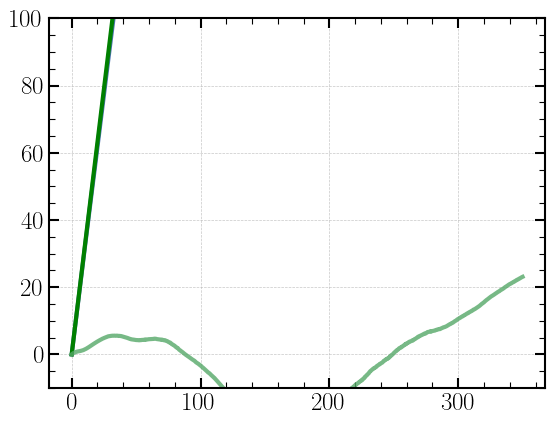

In [6]:
fc = CompareRuns(r_cl0=1000, vturb=120, rundir='/viper/ptmp/ferhi/InfallTurbulent/H_test/g1e10/r1e3/m0.8', Lambda_units=1) 
fc.compare_plots(100, stop_mode='time')

this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 22.56
This is Tcool0: 0.0016408768179999491
This is gtgrow0: 21.410614116294663
-9.999999842814751e-11
-9.999998238052116e-11
-9.99999743569588e-11
-9.999993424163001e-11
-9.999992711045045e-11
-9.999991819666044e-11
-9.999991819666044e-11
-9.999975778337919e-11
-9.9999677601867e-11
-9.999927694350842e-11
-9.999920575902406e-11
-9.999911679698889e-11
-9.999911679698889e-11
-9.999751901484021e-11
-9.999672268232129e-11
-9.99927668316071e-11
-9.999206815583689e-11
-9.999119678882108e-11
-9.99911967888089e-11
-9.997590436684287e-11
-9.996855639109888e-11
-9.993516095255531e-11
-9.992985852451444e-11
-9.992351806646889e-11
-9.992351791684217e-11
-9.986866118577891e-11
-9.988056284644355e-11
-9.983906664229982e-11
-9.976733779304839e-11
-9.969227462711663e-11
-9.969305176285021e-11
-9.951098082067649e-11
-9.940850528462293e-11
-9.911553132730042e-11
-9.90805687

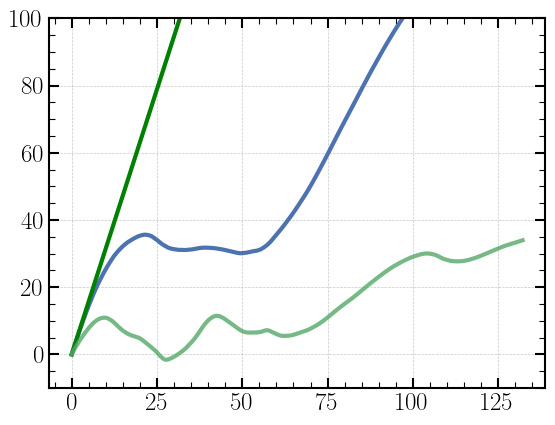

In [13]:
fc = CompareRuns(r_cl0=100, vturb=40, rundir='/viper/ptmp/ferhi/StratDisk/m0.3/r100/burnin')
fc.compare_plots(100, stop_mode='time')

this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 22.56
This is Tcool0: 0.0016408768179999491
This is gtgrow0: 17.18404908093376
-9.999999842814751e-11
-1.0000000728881816e-10
-1.0000001171889663e-10
-1.0000003386671239e-10
-1.0000003780365258e-10
-1.0000004272463706e-10
-1.0000004272463706e-10
-1.0000013126606954e-10
-1.0000017551108009e-10
-1.0000039647807671e-10
-1.0000043571607317e-10
-1.0000048474444042e-10
-1.0000048474444042e-10
-1.000013636085222e-10
-1.0000180044991462e-10
-1.0000395846337191e-10
-1.000043375122034e-10
-1.0000480935806408e-10
-1.0000480935805681e-10
-1.0001292135852056e-10
-1.0001670015523239e-10
-1.0003266211551184e-10
-1.0003497031217379e-10
-1.0003762475418052e-10
-1.0003762472223772e-10
-1.0004174215282137e-10
-1.0001743457084198e-10
-9.998515229982608e-11
-1.0001324437792022e-10
-1.0001840025702094e-10
-1.000184324701067e-10
-9.980024410595674e-11
-9.975652117387039e-11
-9.9

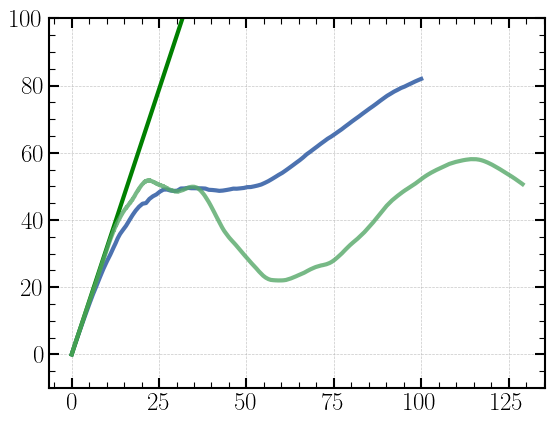

In [14]:
fc = CompareRuns(r_cl0=100, vturb=70, rundir='/viper/ptmp/ferhi/StratDisk/m0.3/r100_v2')
fc.compare_plots(100, stop_mode='time')


this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 16.0
This is Tcool0: 0.000106
This is gtgrow0: 45.77908118670882
-1.0349019790956776e-10
-1.0349018984733373e-10
-1.034901858162359e-10
-1.0349016566093407e-10
-1.0349016207780218e-10
-1.034901575989013e-10
-1.034901575989013e-10
-1.03490076981316e-10
-1.0349003667444128e-10
-1.0348983515880315e-10
-1.0348979933708891e-10
-1.0348975456134187e-10
-1.0348975456134187e-10
-1.0348894886081438e-10
-1.0348854620218161e-10
-1.0348653477936926e-10
-1.0348617752110864e-10
-1.0348573108742383e-10
-1.034857310874245e-10
-1.0347772143084669e-10
-1.0347373560119357e-10
-1.0345399031641821e-10
-1.0345051205780518e-10
-1.0344617771541905e-10
-1.0344617771635113e-10
-1.0337063429201907e-10
-1.0333460158923581e-10
-1.0316978585892048e-10
-1.0314294340672524e-10
-1.0311033864518018e-10
-1.0311034188397636e-10
-1.0264898527687355e-10
-1.0246450757157153e-10
-1.01075525140946

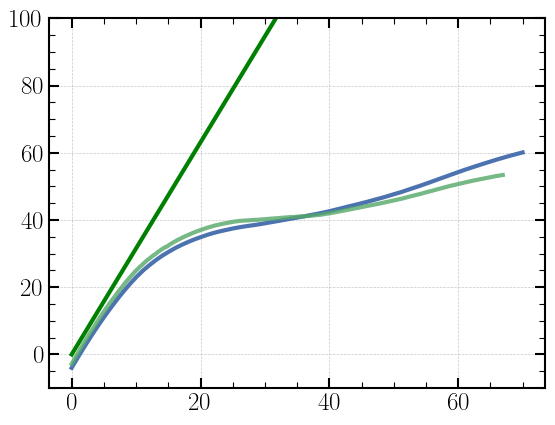

In [34]:
fc = CompareRuns(r_cl0=100, vturb = 15, tcool = 1.06e-4, rundir='/viper/ptmp/ferhi/StratDisk/OldRuns/Rsys/m0.1/r100/t1e3', v0 = 4, cooling_factor=1.7)
fc.compare_plots(70)

this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.5338013090225301
-4.978409483959839e-10
-4.96837548511469e-10
-4.963416684849495e-10
-4.939202691381628e-10
-4.934998932267243e-10
-4.929786976652252e-10
-4.929786976666027e-10
-4.844024401175822e-10
-4.806799039636731e-10
-4.67546681024021e-10
-4.661418591459442e-10
-4.64769350291936e-10
-4.6476936174607873e-10
-5.061988020606951e-10
-5.671358766615206e-10
-1.1000940399135066e-09
-1.2083028911325684e-09
-1.3383488263949707e-09
-1.3387532713884074e-09
-8.176785899056554e-10
-1.516422771257197e-09
-1.533007261536983e-09
-7.326399461764782e-10
-1.2474069735989029e-09
-1.5841913919705116e-09
-1.0531813783570297e-09
-1.4111935190110129e-09
-8.740593501435254e-10
-1.284228873757027e-09
-1.0099704118795627e-09
-1.1734465948493724e-09
-1.2857674592542148e-09
-1.5064713619477944e-09
-1.45619702364308e-09


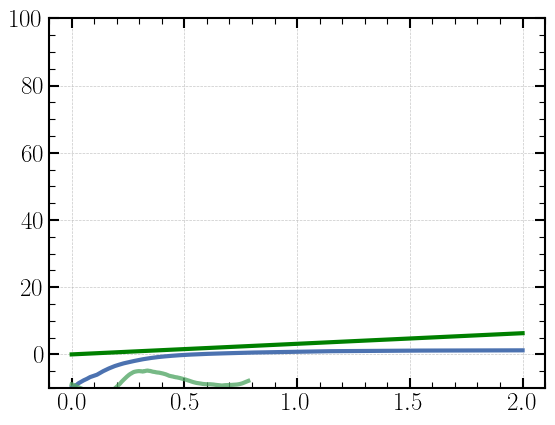

In [37]:
fc = CompareRuns(0.3, h0=20, vturb =10, rundir='/viper/ptmp/ferhi/StratDisk/OldRuns/tgrowtff/m0.1/h20', v0=10)
fc.compare_plots(2)